# EDA de IBEX35, S&P500 y Oro
Este notebook reconstruye el análisis exploratorio de datos usando `load_data.py` para descargar datos de Yahoo Finance, generar indicadores técnicos y explorar las series del IBEX35, S&P500 y el oro.

El objetivo es: 1) comparar series temporales normalizadas, 2) analizar retornos y correlaciones, y 3) revisar las características técnicas que usarán los modelos.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from load_data import DataProcessor

In [3]:
tickers = {
    'IBEX35': '^IBEX',
    'S&P500': '^GSPC',
    'Gold': 'GC=F'
}

assets = {}
for name, ticker in tickers.items():
    processor = DataProcessor(ticker=ticker, start_date='2000-01-01', end_date='2025-01-01')
    df = processor.download_data()
    processor.add_features()
    assets[name] = processor.data.copy()

for name, df in assets.items():
    print(f'{name}: {df.shape[0]} filas, {df.shape[1]} columnas')

Descargando datos para ^IBEX...


[*********************100%***********************]  1 of 1 completed


Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Descargando datos para ^GSPC...


[*********************100%***********************]  1 of 1 completed


Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Descargando datos para GC=F...


[*********************100%***********************]  1 of 1 completed

Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
IBEX35: 6159 filas, 13 columnas
S&P500: 6090 filas, 13 columnas
Gold: 5907 filas, 13 columnas


## Comparación de precios normalizados
Normalizamos cada serie para comparar la evolución relativa desde el mismo punto de partida, independiente de la escala original.

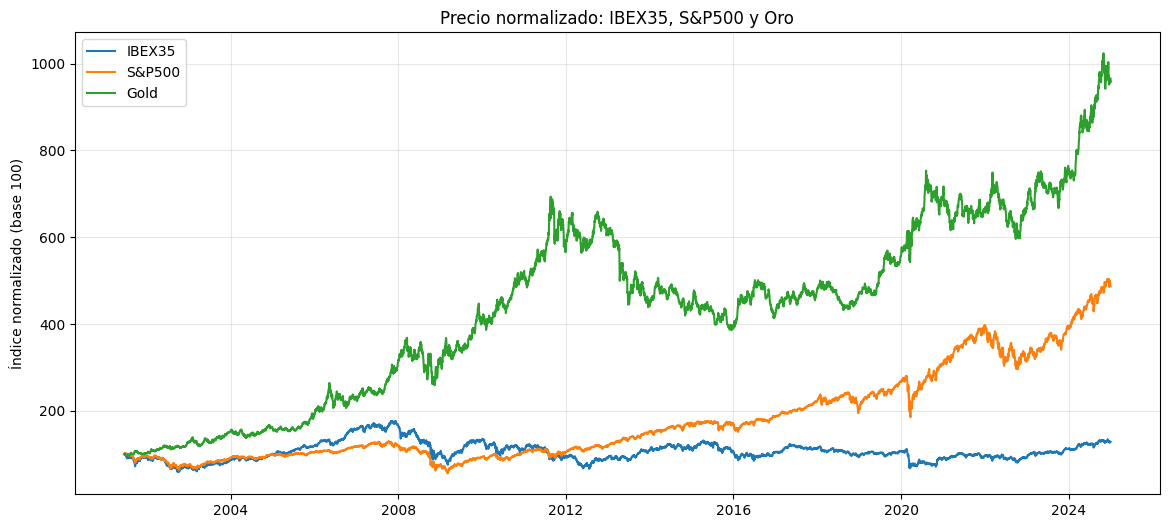

In [4]:
common_index = assets['IBEX35'].index
for df in assets.values():
    common_index = common_index.intersection(df.index)

prices = pd.DataFrame({name: assets[name].loc[common_index, 'Close'] for name in assets})
prices_norm = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
for column in prices_norm.columns:
    ax.plot(prices_norm.index, prices_norm[column], label=column)

ax.set_title('Precio normalizado: IBEX35, S&P500 y Oro')
ax.set_ylabel('Índice normalizado (base 100)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

## Retornos, correlaciones y estadísticas
Analizamos los retornos diarios logarítmicos (la característica `Log_Ret` generada por `load_data.py`) y su correlación entre activos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16952\924932484.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns = pd.concat([assets[name]['Log_Ret'].rename(name) for name in assets], axis=1).dropna()


,mean,std,min,max,annualized_vol
IBEX35,0.000040,0.014081,-0.151512,0.134836,0.2235
S&P500,0.000239,0.012131,-0.127652,0.109572,0.1926
Gold,0.000342,0.010923,-0.098206,0.086432,0.1734


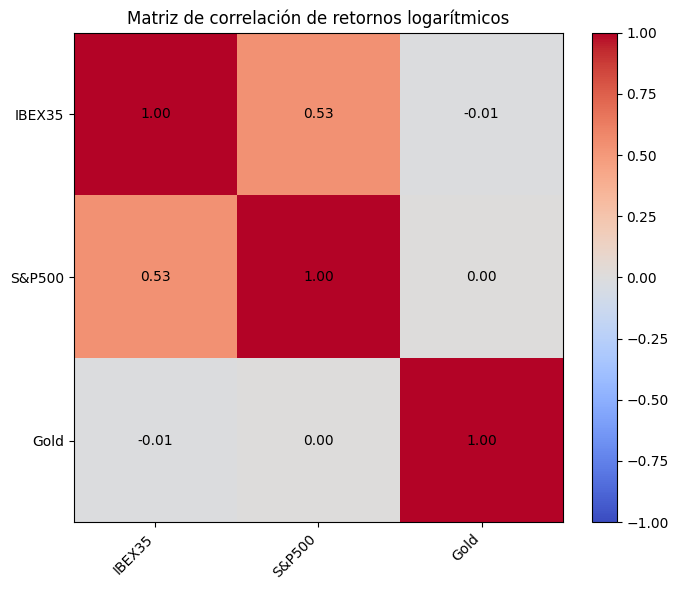

In [5]:
returns = pd.concat([assets[name]['Log_Ret'].rename(name) for name in assets], axis=1).dropna()
corr = returns.corr()

summary = returns.agg(['mean', 'std', 'min', 'max']).T
summary['annualized_vol'] = summary['std'] * np.sqrt(252)
display(summary.style.format({
    'mean': '{:.6f}',
    'std': '{:.6f}',
    'min': '{:.6f}',
    'max': '{:.6f}',
    'annualized_vol': '{:.4f}'
}))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
ax.set_title('Matriz de correlación de retornos logarítmicos')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Revisión de indicadores técnicos
Mostramos las últimas filas de los indicadores generados por `load_data.py` para cada activo.

In [6]:
for name, df in assets.items():
    print(f'--- {name} ---')
    display(df[['Close', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'SMA_50', 'SMA_200']].tail(5))

--- IBEX35 ---


Price,Close,Log_Ret,Volatilidad,RSI_14,MACD_12_26_9,MACDh_12_26_9,SMA_50,SMA_200
Date,,,,,,,,
2024-12-23,11435.700195,-0.002759,0.008395,36.914659,-52.260411,-53.696481,11725.609922,11294.323491
2024-12-24,11473.900391,0.003335,0.008291,39.305142,-61.347204,-50.226618,11716.483926,11299.240493
2024-12-27,11531.599609,0.005016,0.008357,42.829029,-63.164586,-41.635200,11707.181914,11303.908989
2024-12-30,11536.799805,0.000451,0.008331,43.149390,-63.453805,-33.539536,11699.827910,11308.609487
2024-12-31,11595.000000,0.005032,0.008393,46.746096,-58.314531,-22.720209,11693.223906,11313.077485


--- S&P500 ---


Price,Close,Log_Ret,Volatilidad,RSI_14,MACD_12_26_9,MACDh_12_26_9,SMA_50,SMA_200
Date,,,,,,,,
2024-12-24,6040.040039,0.010982,0.008843,55.687903,9.407258,-14.761404,5933.808203,5535.671353
2024-12-26,6037.589844,-0.000406,0.008756,55.420297,12.219774,-9.559111,5938.254805,5539.982952
2024-12-27,5970.839844,-0.011117,0.009076,48.572368,8.959269,-10.255692,5940.822197,5544.010601
2024-12-30,5906.939941,-0.010760,0.009258,43.084036,1.205215,-14.407798,5942.131592,5547.792900
2024-12-31,5881.629883,-0.004294,0.009247,41.102957,-6.902670,-18.012546,5942.470791,5551.615601


--- Gold ---


Price,Close,Log_Ret,Volatilidad,RSI_14,MACD_12_26_9,MACDh_12_26_9,SMA_50,SMA_200
Date,,,,,,,,
2024-12-24,2620.000000,0.002943,0.009532,45.646373,-9.144972,-5.245416,2669.117993,2468.447994
2024-12-26,2638.800049,0.007150,0.009660,48.855933,-8.295974,-3.517135,2668.665996,2470.839995
2024-12-27,2617.199951,-0.008219,0.009690,45.529411,-9.259349,-3.584408,2667.529995,2473.048995
2024-12-30,2606.100098,-0.004250,0.009584,43.876126,-10.794069,-4.095302,2665.831997,2475.264496
2024-12-31,2629.199951,0.008825,0.009657,48.099898,-10.030752,-2.665588,2664.141997,2477.623995


## Conclusiones rápidas
- El notebook usa `load_data.py` para descargar datos históricos y generar las mismas características que se usarán en el modelo CNN-AE.
- La comparación de precios normalizados permite ver cambios de régimen relativos entre IBEX35, S&P500 y oro.
- La matriz de correlación muestra si los retornos de oro actúan como cobertura frente a los índices bursátiles.